# Part 2: Modeling Loss

This notebook implements the required ordinary linear regression, diagnoses why it is a poor fit for the severity distribution, compares it with a two-stage hurdle model, and scores the unlabeled loans.

The workflow is deliberately split into short, reviewable stages. All preprocessing is learned only from each training partition, and all validation splits are grouped by property so that loans backed by the same property cannot cross a train-validation boundary.

## Analysis decisions

- **Prediction timing:** The primary task is treated as current-state severity estimation because the scoring file contains current occupancy, current NOI, and delinquency flags. An origination-only linear model is retained as a timing sensitivity.
- **Target policy:** The assignment defines severity on `[0, 1]`; the 108 supplied observations above one are clipped for the primary analysis and retained unchanged in a separately labeled sensitivity.
- **Validation:** The headline result uses a fixed 80/20 property-grouped holdout. Three repetitions of five-fold grouped cross-validation provide a stability check.
- **Alternative model:** The hurdle model estimates loss occurrence and positive-loss magnitude separately, then multiplies them into expected severity.

## 1. Setup and paths

In [1]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
from IPython.display import Image, display
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import (
    HistGradientBoostingClassifier,
    HistGradientBoostingRegressor,
)
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    average_precision_score,
    brier_score_loss,
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    roc_auc_score,
)
from sklearn.model_selection import GroupKFold, GroupShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

RANDOM_SEED = 20260901
VALIDATION_SIZE = 0.20
CV_FOLDS = 5
CV_REPEATS = 3

EXPECTED_LOAN_COLUMNS = [
    "loan_id", "propname", "orig_date", "end_date", "loan_size_mm",
    "ltv", "occ_at_orig", "occ", "noi_at_orig", "noi",
    "is_30d", "is_90d", "severity",
]
EXPECTED_PROPERTY_COLUMNS = [
    "propname", "cssaproptype", "proptype", "proptypelong",
    "state", "msa_category", "year_built", "sqft",
]

ORIGINATION_NUMERIC_FEATURES = [
    "log_loan_size", "ltv_fraction", "occ_at_orig_fraction",
    "signed_log_noi_orig", "loan_term_years", "origination_year",
    "property_age", "property_age_invalid", "log_sqft",
]
CURRENT_STATE_NUMERIC_FEATURES = ORIGINATION_NUMERIC_FEATURES + [
    "occ_fraction", "occupancy_change", "signed_log_noi_current",
    "noi_relative_change", "is_30d", "is_90d",
]
CATEGORICAL_FEATURES = ["cssaproptype", "msa_category", "state", "office_group"]

# The notebook works when the CSVs are beside it or one directory above it.
required_files = ["loan_data.csv", "property_data.csv", "predictions.csv"]
candidate_roots = [Path.cwd(), Path.cwd().parent]
ROOT = next(
    (path for path in candidate_roots if all((path / name).exists() for name in required_files)),
    None,
)
if ROOT is None:
    raise FileNotFoundError(
        "Could not find loan_data.csv, property_data.csv, and predictions.csv "
        "in the current directory or its parent."
    )

LOAN_PATH = ROOT / "loan_data.csv"
PROPERTY_PATH = ROOT / "property_data.csv"
PREDICTION_PATH = ROOT / "predictions.csv"
OUTPUT_DIR = ROOT / "outputs"
FIGURE_DIR = OUTPUT_DIR / "figures"
METRIC_DIR = OUTPUT_DIR / "metrics"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
METRIC_DIR.mkdir(parents=True, exist_ok=True)

print(
    "Located all three input CSVs.\n"
    f"pandas={pd.__version__}; numpy={np.__version__}; "
    f"scikit-learn={sklearn.__version__}; seed={RANDOM_SEED}"
)

Located all three input CSVs.
pandas=2.2.3; numpy=2.1.3; scikit-learn=1.6.1; seed=20260901


## 2. Load and validate the source data

In [2]:
def require(condition: bool, message: str) -> None:
    """Raise a readable data-contract error when a required condition fails."""
    if not condition:
        raise ValueError(message)


def normalized_text(series: pd.Series) -> pd.Series:
    """Normalize category labels without replacing missing values."""
    return (
        series.astype("string")
        .str.strip()
        .str.casefold()
        .str.replace(r"[\s_-]+", " ", regex=True)
    )


def load_and_validate(
    loan_path: Path, property_path: Path, prediction_path: Path
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """Load inputs and enforce the schema, key, target, and merge contracts."""
    loans = pd.read_csv(loan_path)
    properties = pd.read_csv(property_path)
    scoring = pd.read_csv(prediction_path)

    # Fail early if the supplied files no longer match the assignment contract.
    require(loans.columns.tolist() == EXPECTED_LOAN_COLUMNS, "Unexpected loan schema")
    require(
        scoring.columns.tolist() == EXPECTED_LOAN_COLUMNS, "Unexpected scoring schema"
    )
    require(
        properties.columns.tolist() == EXPECTED_PROPERTY_COLUMNS,
        "Unexpected property schema",
    )
    require(loans["loan_id"].is_unique, "Training loan_id must be unique")
    require(scoring["loan_id"].is_unique, "Scoring loan_id must be unique")
    require(
        set(loans["loan_id"]).isdisjoint(scoring["loan_id"]),
        "Train/scoring loan IDs overlap",
    )
    require(properties["propname"].is_unique, "Property propname must be unique")
    require(loans["severity"].notna().all(), "Training severity must be populated")
    require(scoring["severity"].isna().all(), "Scoring severity must be blank")
    require(loans["severity"].ge(0).all(), "Severity must be nonnegative")
    require((~loans["is_90d"] | loans["is_30d"]).all(), "is_90d must imply is_30d")

    # One property can back several loans, but each loan must match exactly one
    # property row. The indicator makes unmatched keys explicit.
    def merge(frame: pd.DataFrame, label: str) -> pd.DataFrame:
        merged = frame.merge(
            properties,
            on="propname",
            how="left",
            validate="many_to_one",
            indicator=True,
        )
        require(len(merged) == len(frame), f"{label} merge changed row count")
        require(merged["_merge"].eq("both").all(), f"Unmatched {label} properties")
        return merged.drop(columns="_merge")

    return merge(loans, "development"), merge(scoring, "scoring"), scoring


In [3]:
development, scoring, scoring_source = load_and_validate(
    LOAN_PATH, PROPERTY_PATH, PREDICTION_PATH
)

raw_target = development["severity"]
target = raw_target.clip(0, 1)

data_summary = pd.DataFrame(
    {
        "rows": [len(development), len(scoring)],
        "properties": [development["propname"].nunique(), scoring["propname"].nunique()],
        "severity missing": [raw_target.isna().sum(), scoring["severity"].isna().sum()],
    },
    index=["development", "scoring"],
)
display(data_summary)
print(
    f"Severity is zero for {target.eq(0).mean():.2%} of development loans; "
    f"{raw_target.gt(1).sum():,} supplied values exceed one."
)

,rows,properties,severity missing
development,39699,36978,0
scoring,1000,996,1000


Severity is zero for 83.93% of development loans; 108 supplied values exceed one.


## 3. Engineer model features

In [4]:
def classify_office_group(frame: pd.DataFrame) -> np.ndarray:
    """Assign the Part 1 office-exposure grouping for use as a model feature."""
    cssa = normalized_text(frame["cssaproptype"])
    broad_type = normalized_text(frame["proptype"])
    detailed_type = normalized_text(frame["proptypelong"])
    is_office = cssa.eq("of")
    is_mixed = cssa.eq("mu") | broad_type.eq("mixed use")
    has_office = detailed_type.str.contains(r"\boffice\b", regex=True, na=False)
    unknown_mixed = is_mixed & detailed_type.isna()
    return np.select(
        [is_office, ~is_office & has_office, unknown_mixed],
        ["office", "mixed office", "unknown mixed"],
        default="non office",
    )


def engineer_features(frame: pd.DataFrame) -> pd.DataFrame:
    """Create the same economically motivated features for training and scoring."""
    # Dates become model-friendly term, vintage, and property-age features.
    origination = pd.to_datetime(frame["orig_date"], errors="coerce")
    maturity = pd.to_datetime(frame["end_date"], errors="coerce")
    require(origination.notna().all(), "orig_date contains unparseable values")
    require(maturity.notna().all(), "end_date contains unparseable values")

    features = pd.DataFrame(index=frame.index)

    # Loan structure and current operating condition. Log transforms reduce the
    # influence of very large loans and NOI values while signed logs retain losses.
    features["log_loan_size"] = np.log1p(frame["loan_size_mm"])
    features["ltv_fraction"] = frame["ltv"] / 100
    features["occ_at_orig_fraction"] = frame["occ_at_orig"] / 100
    features["occ_fraction"] = frame["occ"] / 100
    features["occupancy_change"] = (frame["occ"] - frame["occ_at_orig"]) / 100
    features["signed_log_noi_orig"] = np.sign(frame["noi_at_orig"]) * np.log1p(
        frame["noi_at_orig"].abs()
    )
    features["signed_log_noi_current"] = np.sign(frame["noi"]) * np.log1p(
        frame["noi"].abs()
    )
    # A denominator floor avoids division by values near zero. The final clipping
    # prevents a few extreme changes from dominating the linear regression.
    noi_denominator = frame["noi_at_orig"].abs().clip(lower=1)
    features["noi_relative_change"] = (
        (frame["noi"] - frame["noi_at_orig"]) / noi_denominator
    ).clip(-5, 5)
    features["is_30d"] = frame["is_30d"].astype(float)
    features["is_90d"] = frame["is_90d"].astype(float)
    features["loan_term_years"] = (maturity - origination).dt.days / 365.25
    features["origination_year"] = origination.dt.year.astype(float)

    # Negative implied ages are data-quality problems: retain that information in
    # a flag, then let the preprocessing pipeline impute the invalid age itself.
    property_age = origination.dt.year - frame["year_built"]
    features["property_age_invalid"] = property_age.lt(0).astype(float)
    features["property_age"] = property_age.mask(property_age.lt(0))
    features["log_sqft"] = np.log1p(frame["sqft"])

    # Normalize categories once so training and scoring use identical labels.
    features["cssaproptype"] = normalized_text(frame["cssaproptype"])
    features["msa_category"] = normalized_text(frame["msa_category"])
    features["state"] = normalized_text(frame["state"])
    features["office_group"] = classify_office_group(frame)
    return features


In [5]:
features = engineer_features(development)
scoring_features = engineer_features(scoring)

require(
    features.columns.tolist() == scoring_features.columns.tolist(),
    "Development and scoring feature schemas differ",
)

feature_audit = pd.DataFrame(
    {
        "development missing": features.isna().sum(),
        "scoring missing": scoring_features.isna().sum(),
        "development unique": features.nunique(dropna=True),
    }
)
display(feature_audit)

,development missing,scoring missing,development unique
log_loan_size,0,0,23874
ltv_fraction,0,0,3568
occ_at_orig_fraction,2027,40,4995
occ_fraction,1609,33,5326
occupancy_change,2027,40,2386
signed_log_noi_orig,0,0,39690
signed_log_noi_current,0,0,39693
noi_relative_change,0,0,39680
is_30d,0,0,2
is_90d,0,0,2


## 4. Define preprocessing and models

In [6]:
def build_preprocessor(
    numeric_features: list[str], *, dense_output: bool = False
) -> ColumnTransformer:
    """Build fold-safe numeric and categorical preprocessing."""
    # Missingness indicators preserve whether an originally observed value was
    # absent; medians and scaling are learned only from the training partition.
    numeric = Pipeline(
        [
            ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
            ("scaler", StandardScaler()),
        ]
    )
    # Unknown-category handling allows scoring rows to contain labels not seen in
    # model development. Tree models request dense output below.
    categorical = Pipeline(
        [
            ("imputer", SimpleImputer(strategy="most_frequent")),
            (
                "encoder",
                OneHotEncoder(
                    handle_unknown="ignore",
                    sparse_output=not dense_output,
                ),
            ),
        ]
    )
    return ColumnTransformer(
        [
            ("numeric", numeric, numeric_features),
            ("categorical", categorical, CATEGORICAL_FEATURES),
        ],
        sparse_threshold=0 if dense_output else 0.3,
    )


def build_linear_pipeline(numeric_features: list[str]) -> Pipeline:
    """Combine preprocessing with the assignment's required OLS model."""
    return Pipeline(
        [
            ("preprocessor", build_preprocessor(numeric_features)),
            ("model", LinearRegression()),
        ]
    )


class HurdleSeverityModel:
    """Model bounded expected severity as probability times positive-loss magnitude."""

    def __init__(self, seed: int) -> None:
        self.preprocessor = build_preprocessor(
            CURRENT_STATE_NUMERIC_FEATURES, dense_output=True
        )
        self.occurrence_model = HistGradientBoostingClassifier(
            learning_rate=0.06,
            max_iter=220,
            max_leaf_nodes=15,
            l2_regularization=1.0,
            random_state=seed,
        )
        self.magnitude_model = HistGradientBoostingRegressor(
            loss="poisson",
            learning_rate=0.05,
            max_iter=220,
            max_leaf_nodes=15,
            l2_regularization=1.0,
            random_state=seed,
        )

    def fit(self, features: pd.DataFrame, target: pd.Series) -> HurdleSeverityModel:
        """Fit loss occurrence on all rows and magnitude on positive rows only."""
        matrix = self.preprocessor.fit_transform(features)
        has_loss = target.gt(0)
        require(has_loss.any(), "Hurdle training requires positive losses")
        require((~has_loss).any(), "Hurdle training requires zero losses")
        self.occurrence_model.fit(matrix, has_loss.astype(int))
        self.magnitude_model.fit(matrix[has_loss.to_numpy()], target.loc[has_loss])
        return self

    def predict_components(
        self, features: pd.DataFrame
    ) -> tuple[np.ndarray, np.ndarray]:
        """Return probability of loss and severity conditional on a loss."""
        matrix = self.preprocessor.transform(features)
        probability = self.occurrence_model.predict_proba(matrix)[:, 1]
        magnitude = np.clip(self.magnitude_model.predict(matrix), 0, 1)
        return probability, magnitude

    def predict(self, features: pd.DataFrame) -> np.ndarray:
        """Return expected severity: loss probability times conditional severity."""
        probability, magnitude = self.predict_components(features)
        return probability * magnitude


## 5. Property-grouped holdout evaluation

In [7]:
def calculate_metrics(
    model_name: str,
    y_true: pd.Series | np.ndarray,
    predictions: np.ndarray,
    loan_weights: pd.Series | np.ndarray,
    *,
    target_policy: str = "severity clipped to [0, 1]",
) -> dict[str, float | str]:
    """Calculate fit, error, bias, weighting, and prediction-range diagnostics."""
    y_array = np.asarray(y_true, dtype=float)
    pred_array = np.asarray(predictions, dtype=float)
    weights = np.asarray(loan_weights, dtype=float)
    mse = mean_squared_error(y_array, pred_array)
    return {
        "model": model_name,
        "target_policy": target_policy,
        "r2": r2_score(y_array, pred_array),
        "mse": mse,
        "rmse": np.sqrt(mse),
        "mae": mean_absolute_error(y_array, pred_array),
        "bias": float(np.mean(pred_array - y_array)),
        "loan_balance_weighted_mse": float(
            np.average(np.square(pred_array - y_array), weights=weights)
        ),
        "prediction_min": float(np.min(pred_array)),
        "prediction_max": float(np.max(pred_array)),
        "pct_predictions_below_zero": float(np.mean(pred_array < 0)),
        "pct_predictions_above_one": float(np.mean(pred_array > 1)),
    }


def make_holdout(
    features: pd.DataFrame, target: pd.Series, groups: pd.Series, seed: int
) -> tuple[np.ndarray, np.ndarray]:
    """Create one 80/20 split with no property appearing on both sides."""
    splitter = GroupShuffleSplit(
        n_splits=1, test_size=VALIDATION_SIZE, random_state=seed
    )
    train_index, validation_index = next(
        splitter.split(features, target, groups=groups)
    )
    require(
        set(groups.iloc[train_index]).isdisjoint(groups.iloc[validation_index]),
        "A property crosses the holdout boundary",
    )
    positive_gap = abs(
        target.iloc[train_index].gt(0).mean()
        - target.iloc[validation_index].gt(0).mean()
    )
    require(positive_gap < 0.02, "Holdout positive-severity rates differ materially")
    return train_index, validation_index


def evaluate_holdout(
    features: pd.DataFrame,
    target: pd.Series,
    raw_target: pd.Series,
    development: pd.DataFrame,
    train_index: np.ndarray,
    validation_index: np.ndarray,
    seed: int,
) -> dict[str, object]:
    """Fit all headline models on one shared property-grouped holdout."""
    # Every model sees the same train/validation rows, enabling paired comparison.
    x_train = features.iloc[train_index]
    x_validation = features.iloc[validation_index]
    y_train = target.iloc[train_index]
    y_validation = target.iloc[validation_index]
    raw_y_train = raw_target.iloc[train_index]
    raw_y_validation = raw_target.iloc[validation_index]
    weights = development.iloc[validation_index]["loan_size_mm"]
    metric_rows: list[dict[str, float | str]] = []

    # Simple references show whether a fitted model beats naive severity guesses.
    zero_predictions = np.zeros(len(y_validation))
    metric_rows.append(
        calculate_metrics("all_zero_baseline", y_validation, zero_predictions, weights)
    )
    mean_model = DummyRegressor(strategy="mean").fit(
        np.zeros((len(y_train), 1)), y_train
    )
    mean_predictions = mean_model.predict(np.zeros((len(y_validation), 1)))
    metric_rows.append(
        calculate_metrics(
            "training_mean_baseline", y_validation, mean_predictions, weights
        )
    )

    # Timing sensitivity: this version excludes current NOI, occupancy, and
    # delinquency, which would be unavailable in an origination-time forecast.
    origination_linear = build_linear_pipeline(ORIGINATION_NUMERIC_FEATURES)
    origination_linear.fit(x_train, y_train)
    origination_predictions = origination_linear.predict(x_validation)
    metric_rows.append(
        calculate_metrics(
            "linear_origination_only",
            y_validation,
            origination_predictions,
            weights,
        )
    )

    # Required linear regression under the primary current-state interpretation.
    current_linear = build_linear_pipeline(CURRENT_STATE_NUMERIC_FEATURES)
    current_linear.fit(x_train, y_train)
    linear_predictions = current_linear.predict(x_validation)
    metric_rows.append(
        calculate_metrics(
            "linear_current_state", y_validation, linear_predictions, weights
        )
    )

    # Target-policy sensitivity: retain supplied values above one rather than
    # clipping them to the range stated in the assignment.
    raw_linear = build_linear_pipeline(CURRENT_STATE_NUMERIC_FEATURES)
    raw_linear.fit(x_train, raw_y_train)
    raw_predictions = raw_linear.predict(x_validation)
    metric_rows.append(
        calculate_metrics(
            "linear_current_state_raw_sensitivity",
            raw_y_validation,
            raw_predictions,
            weights,
            target_policy="raw supplied severity",
        )
    )

    # Alternative model: separately estimate whether a loss occurs and how large
    # it is, then multiply the two components into expected severity.
    hurdle_model = HurdleSeverityModel(seed).fit(x_train, y_train)
    positive_probability, conditional_magnitude = hurdle_model.predict_components(
        x_validation
    )
    hurdle_predictions = positive_probability * conditional_magnitude
    metric_rows.append(
        calculate_metrics(
            "hurdle_current_state", y_validation, hurdle_predictions, weights
        )
    )

    # Evaluate the two hurdle components as well as their combined prediction.
    has_loss = y_validation.gt(0)
    hurdle_components = {
        "roc_auc": roc_auc_score(has_loss, positive_probability),
        "average_precision": average_precision_score(has_loss, positive_probability),
        "brier_score": brier_score_loss(has_loss, positive_probability),
        "positive_magnitude_mae": mean_absolute_error(
            y_validation.loc[has_loss],
            conditional_magnitude[has_loss.to_numpy()],
        ),
    }
    return {
        "metrics": pd.DataFrame(metric_rows),
        "y_validation": y_validation,
        "linear_predictions": linear_predictions,
        "hurdle_predictions": hurdle_predictions,
        "hurdle_components": hurdle_components,
    }


def plot_actual_vs_predicted(
    y_true: pd.Series,
    predictions: np.ndarray,
    metrics: pd.Series,
    output_path: Path,
    *,
    model_label: str,
    title: str,
    color: str,
    axis_limits: tuple[float, float],
) -> None:
    """Save the required true-versus-predicted severity scatter plot."""
    lower, upper = axis_limits
    fig, ax = plt.subplots(figsize=(8.4, 7.0))
    ax.scatter(
        y_true,
        predictions,
        s=14,
        alpha=0.22,
        color=color,
        edgecolors="none",
        rasterized=True,
    )
    ax.plot(
        [lower, upper],
        [lower, upper],
        linestyle="--",
        color="#DC2626",
        linewidth=1.5,
        label="Perfect prediction",
    )
    ax.axhline(0, color="#64748B", linewidth=0.9)
    ax.set(xlim=(lower, upper), ylim=(lower, upper))
    ax.set_xlabel("True severity")
    ax.set_ylabel(f"{model_label} predicted severity")
    ax.set_title(title, loc="left", fontsize=15, fontweight="bold", pad=12)
    ax.legend(loc="upper left", frameon=False)
    ax.grid(color="#CBD5E1", alpha=0.55)
    ax.spines[["top", "right"]].set_visible(False)
    metric_text = (
        f"Grouped holdout (n={len(y_true):,})\n"
        f"R² = {metrics['r2']:.3f}\n"
        f"MSE = {metrics['mse']:.4f}\n"
        f"MAE = {metrics['mae']:.4f}\n"
        f"Predictions < 0: {metrics['pct_predictions_below_zero']:.1%}\n"
        f"Predictions > 1: {metrics['pct_predictions_above_one']:.1%}"
    )
    ax.text(
        0.98,
        0.04,
        metric_text,
        transform=ax.transAxes,
        ha="right",
        va="bottom",
        bbox={
            "boxstyle": "round,pad=0.5",
            "facecolor": "white",
            "edgecolor": "#CBD5E1",
        },
    )
    fig.tight_layout()
    fig.savefig(output_path, dpi=200, bbox_inches="tight", facecolor="white")
    plt.close(fig)


In [8]:
train_index, validation_index = make_holdout(
    features, target, development["propname"], RANDOM_SEED
)
print(
    f"Training loans: {len(train_index):,}\n"
    f"Validation loans: {len(validation_index):,}\n"
    "Property overlap: 0"
)

holdout = evaluate_holdout(
    features,
    target,
    raw_target,
    development,
    train_index,
    validation_index,
    RANDOM_SEED,
)
metrics = holdout["metrics"]
y_validation = holdout["y_validation"]
linear_predictions = holdout["linear_predictions"]
hurdle_predictions = holdout["hurdle_predictions"]

display_columns = [
    "model", "target_policy", "r2", "mse", "rmse", "mae",
    "prediction_min", "prediction_max", "pct_predictions_below_zero",
]
display(metrics[display_columns].round(6))

components = holdout["hurdle_components"]
print(
    "Hurdle occurrence and magnitude diagnostics: "
    f"ROC-AUC={components['roc_auc']:.4f}, "
    f"average precision={components['average_precision']:.4f}, "
    f"Brier={components['brier_score']:.4f}, "
    f"positive-magnitude MAE={components['positive_magnitude_mae']:.4f}."
)

Training loans: 31,790
Validation loans: 7,909
Property overlap: 0


,model,target_policy,r2,mse,rmse,mae,prediction_min,prediction_max,pct_predictions_below_zero
0,all_zero_baseline,"severity clipped to [0, 1]",-0.121639,0.042229,0.205498,0.067673,0.000000,0.000000,0.000000
1,training_mean_baseline,"severity clipped to [0, 1]",-0.000023,0.037651,0.194038,0.117969,0.068605,0.068605,0.000000
2,linear_origination_only,"severity clipped to [0, 1]",0.069687,0.035026,0.187153,0.113832,-0.139745,0.244530,0.100266
3,linear_current_state,"severity clipped to [0, 1]",0.525208,0.017876,0.133700,0.064777,-0.185423,0.673206,0.311164
4,linear_current_state_raw_sensitivity,raw supplied severity,0.517905,0.018753,0.136942,0.066208,-0.183780,0.680612,0.317107
5,hurdle_current_state,"severity clipped to [0, 1]",0.595655,0.015224,0.123384,0.047678,0.000053,0.915780,0.000000


Hurdle occurrence and magnitude diagnostics: ROC-AUC=0.9355, average precision=0.8064, Brier=0.0548, positive-magnitude MAE=0.1871.


## 6. Required actual-versus-predicted plot

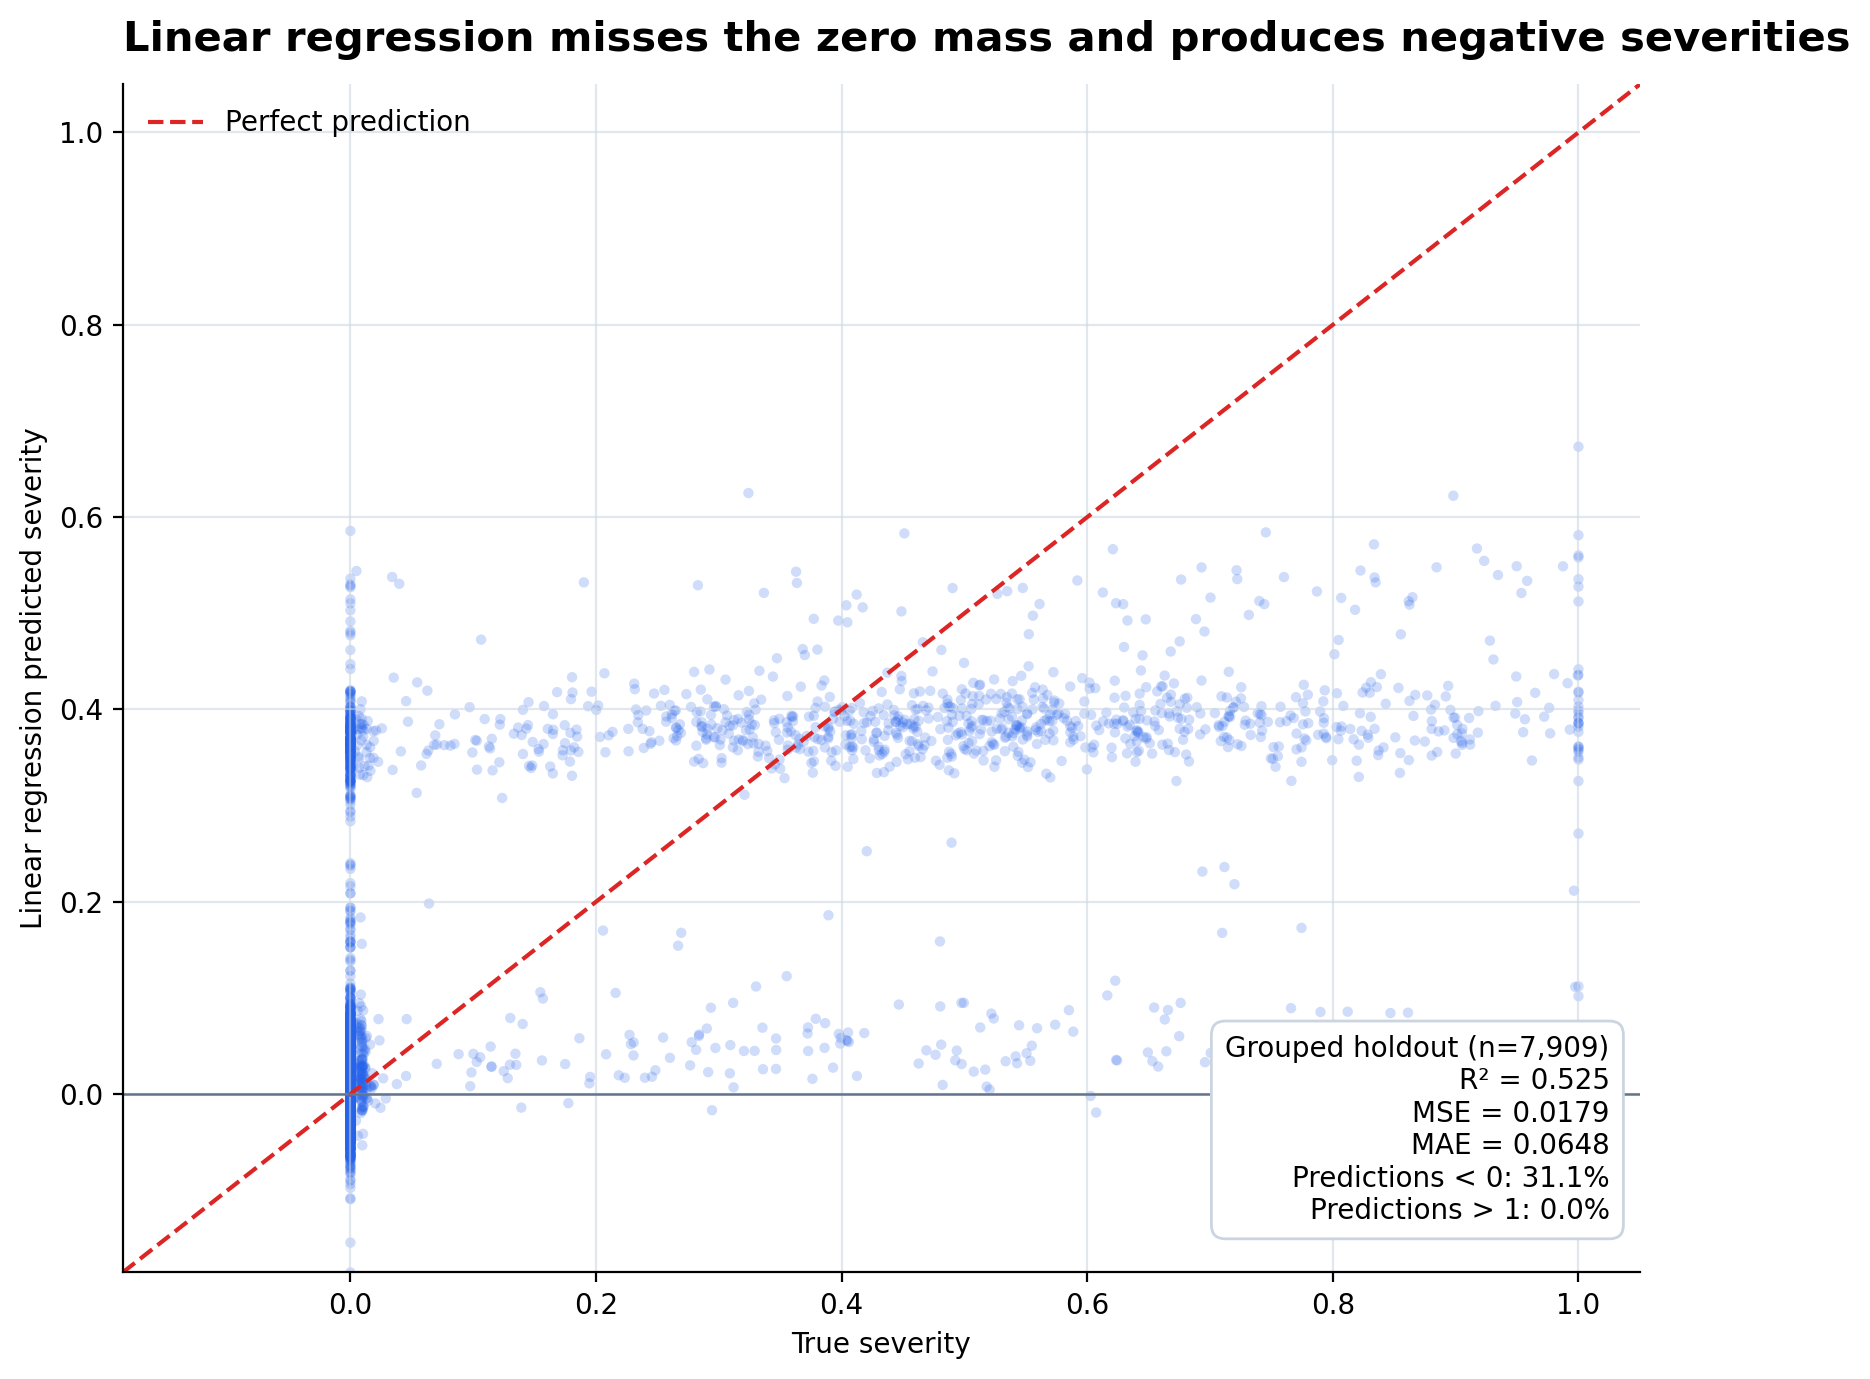

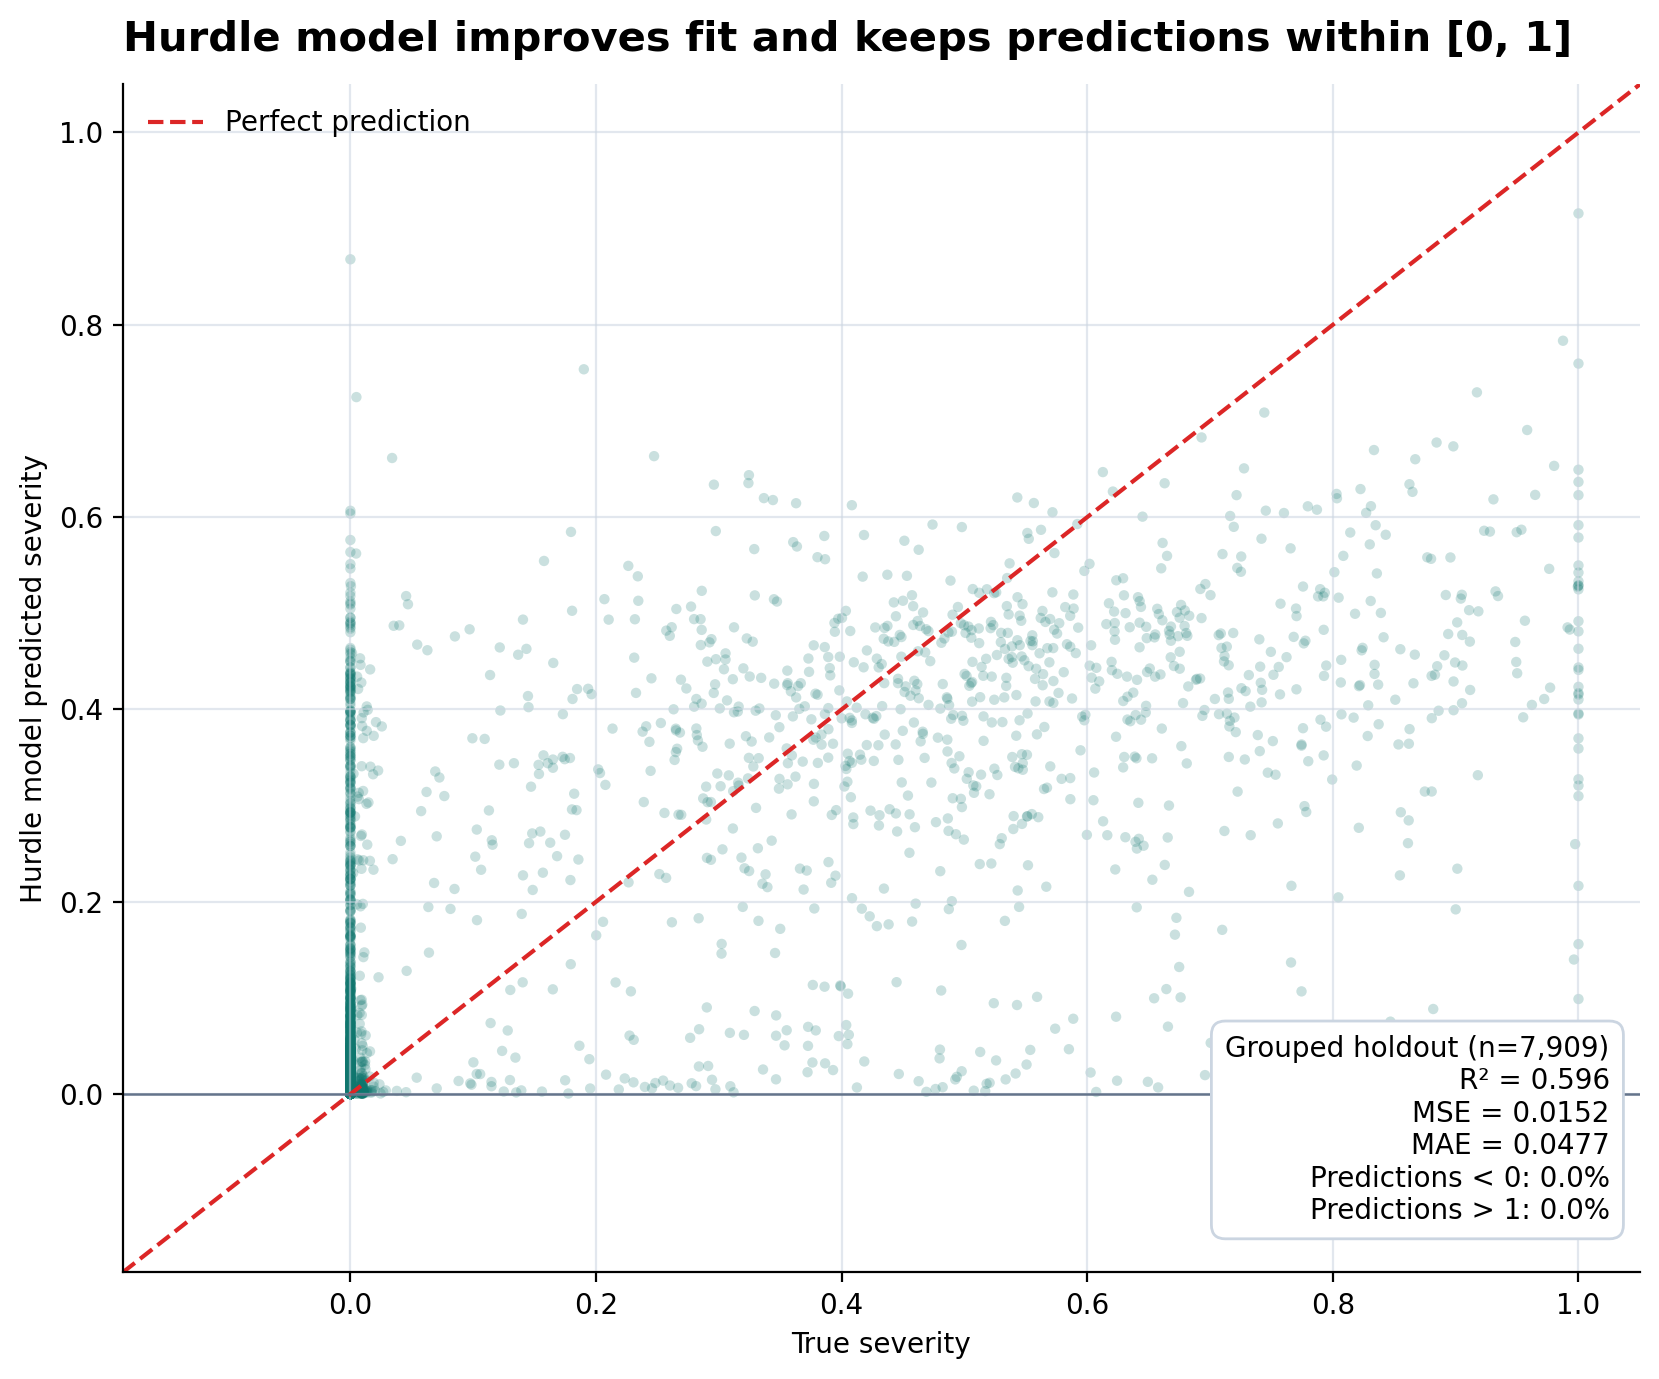

In [9]:
metrics_by_model = metrics.set_index("model")
axis_limits = (
    min(-0.05, float(linear_predictions.min()), float(hurdle_predictions.min())),
    max(
        1.05,
        float(y_validation.max()),
        float(linear_predictions.max()),
        float(hurdle_predictions.max()),
    ),
)

linear_figure = FIGURE_DIR / "part2_linear_actual_vs_predicted.png"
hurdle_figure = FIGURE_DIR / "part2_hurdle_actual_vs_predicted.png"

plot_actual_vs_predicted(
    y_validation,
    linear_predictions,
    metrics_by_model.loc["linear_current_state"],
    linear_figure,
    model_label="Linear regression",
    title="Linear regression misses the zero mass and produces negative severities",
    color="#2563EB",
    axis_limits=axis_limits,
)
plot_actual_vs_predicted(
    y_validation,
    hurdle_predictions,
    metrics_by_model.loc["hurdle_current_state"],
    hurdle_figure,
    model_label="Hurdle model",
    title="Hurdle model improves fit and keeps predictions within [0, 1]",
    color="#0F766E",
    axis_limits=axis_limits,
)

display(Image(filename=str(linear_figure)))
display(Image(filename=str(hurdle_figure)))

## 7. Repeated property-grouped cross-validation

In [10]:
def repeated_group_cv(
    features: pd.DataFrame,
    target: pd.Series,
    development: pd.DataFrame,
    seed: int,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Compare linear and hurdle models on 15 identical property-grouped folds."""
    groups = development["propname"]
    rows: list[dict[str, float | int | str]] = []
    for repeat in range(1, CV_REPEATS + 1):
        splitter = GroupKFold(
            n_splits=CV_FOLDS,
            shuffle=True,
            random_state=seed + repeat - 1,
        )
        for fold, (train_index, validation_index) in enumerate(
            splitter.split(features, target, groups=groups), start=1
        ):
            require(
                set(groups.iloc[train_index]).isdisjoint(groups.iloc[validation_index]),
                "A property crosses a CV fold boundary",
            )
            x_train = features.iloc[train_index]
            x_validation = features.iloc[validation_index]
            y_train = target.iloc[train_index]
            y_validation = target.iloc[validation_index]
            weights = development.iloc[validation_index]["loan_size_mm"]

            linear_model = build_linear_pipeline(CURRENT_STATE_NUMERIC_FEATURES)
            linear_model.fit(x_train, y_train)
            hurdle_model = HurdleSeverityModel(seed + repeat - 1).fit(x_train, y_train)
            predictions = {
                "linear_current_state": linear_model.predict(x_validation),
                "hurdle_current_state": hurdle_model.predict(x_validation),
            }
            for model_name, model_predictions in predictions.items():
                rows.append(
                    {
                        "repeat": repeat,
                        "fold": fold,
                        **calculate_metrics(
                            model_name,
                            y_validation,
                            model_predictions,
                            weights,
                        ),
                    }
                )

    # Summarize performance across folds without treating repeated folds as fully
    # independent statistical samples.
    fold_metrics = pd.DataFrame(rows)
    summary = (
        fold_metrics.groupby(["model", "target_policy"], as_index=False)
        .agg(
            validation_folds=("mse", "size"),
            r2_mean=("r2", "mean"),
            r2_std=("r2", "std"),
            mse_mean=("mse", "mean"),
            mse_std=("mse", "std"),
            rmse_mean=("rmse", "mean"),
            rmse_std=("rmse", "std"),
            mae_mean=("mae", "mean"),
            mae_std=("mae", "std"),
            negative_prediction_share_mean=(
                "pct_predictions_below_zero",
                "mean",
            ),
        )
        .sort_values("mse_mean")
        .reset_index(drop=True)
    )

    # Both models use identical folds, so calculate improvements fold by fold.
    paired_mse = fold_metrics.pivot(
        index=["repeat", "fold"], columns="model", values="mse"
    )
    paired_mae = fold_metrics.pivot(
        index=["repeat", "fold"], columns="model", values="mae"
    )
    linear_mse = paired_mse["linear_current_state"]
    hurdle_mse = paired_mse["hurdle_current_state"]
    linear_mae = paired_mae["linear_current_state"]
    hurdle_mae = paired_mae["hurdle_current_state"]
    fold_mse_reduction = (linear_mse - hurdle_mse) / linear_mse
    fold_mae_reduction = (linear_mae - hurdle_mae) / linear_mae
    comparison = pd.DataFrame(
        [
            {
                "target_policy": "severity clipped to [0, 1]",
                "repeats": CV_REPEATS,
                "folds_per_repeat": CV_FOLDS,
                "paired_folds": len(paired_mse),
                "hurdle_mse_wins": int(hurdle_mse.lt(linear_mse).sum()),
                "hurdle_mae_wins": int(hurdle_mae.lt(linear_mae).sum()),
                "linear_mse_mean": float(linear_mse.mean()),
                "hurdle_mse_mean": float(hurdle_mse.mean()),
                "mse_reduction_from_mean_errors": float(
                    1 - hurdle_mse.mean() / linear_mse.mean()
                ),
                "fold_mse_reduction_mean": float(fold_mse_reduction.mean()),
                "fold_mse_reduction_std": float(fold_mse_reduction.std(ddof=1)),
                "fold_mse_reduction_min": float(fold_mse_reduction.min()),
                "fold_mse_reduction_max": float(fold_mse_reduction.max()),
                "linear_mae_mean": float(linear_mae.mean()),
                "hurdle_mae_mean": float(hurdle_mae.mean()),
                "mae_reduction_from_mean_errors": float(
                    1 - hurdle_mae.mean() / linear_mae.mean()
                ),
                "fold_mae_reduction_mean": float(fold_mae_reduction.mean()),
                "fold_mae_reduction_std": float(fold_mae_reduction.std(ddof=1)),
            }
        ]
    )
    return summary, comparison


In [11]:
cv_summary, cv_comparison = repeated_group_cv(
    features, target, development, RANDOM_SEED
)

metrics.to_csv(METRIC_DIR / "part2_metrics.csv", index=False)
cv_summary.to_csv(METRIC_DIR / "part2_repeated_group_cv_summary.csv", index=False)
cv_comparison.to_csv(
    METRIC_DIR / "part2_repeated_group_cv_comparison.csv", index=False
)

display(cv_summary.round(6))
display(cv_comparison.round(6))

,model,target_policy,validation_folds,r2_mean,r2_std,mse_mean,mse_std,rmse_mean,rmse_std,mae_mean,mae_std,negative_prediction_share_mean
0,hurdle_current_state,"severity clipped to [0, 1]",15,0.600684,0.011112,0.015015,0.000691,0.122504,0.002819,0.047549,0.001298,0.000000
1,linear_current_state,"severity clipped to [0, 1]",15,0.524932,0.008525,0.017859,0.000629,0.133619,0.002356,0.064965,0.001056,0.310823


,target_policy,repeats,folds_per_repeat,paired_folds,hurdle_mse_wins,hurdle_mae_wins,linear_mse_mean,hurdle_mse_mean,mse_reduction_from_mean_errors,fold_mse_reduction_mean,fold_mse_reduction_std,fold_mse_reduction_min,fold_mse_reduction_max,linear_mae_mean,hurdle_mae_mean,mae_reduction_from_mean_errors,fold_mae_reduction_mean,fold_mae_reduction_std
0,"severity clipped to [0, 1]",3,5,15,15,15,0.017859,0.015015,0.159288,0.159536,0.013147,0.133524,0.18161,0.064965,0.047549,0.268076,0.26818,0.009697


## 8. Refit the selected model and score predictions.csv

In [12]:
def score_predictions(
    selected_model: str,
    features: pd.DataFrame,
    target: pd.Series,
    scoring_features: pd.DataFrame,
    scoring_source: pd.DataFrame,
    output_path: Path,
    seed: int,
) -> np.ndarray:
    """Refit the chosen model on all labels and write a scored source-order copy."""
    if selected_model == "hurdle_current_state":
        model = HurdleSeverityModel(seed).fit(features, target)
    elif selected_model == "linear_current_state":
        model = build_linear_pipeline(CURRENT_STATE_NUMERIC_FEATURES)
        model.fit(features, target)
    else:
        raise ValueError(f"Unknown scoring model: {selected_model}")

    predictions = model.predict(scoring_features)

    # Guard the scoring contract before writing anything to disk.
    require(len(predictions) == len(scoring_source), "Scoring row count changed")
    require(np.isfinite(predictions).all(), "Scoring predictions are not finite")
    require(
        ((predictions >= 0) & (predictions <= 1)).all(),
        "Scoring predictions fall outside [0, 1]",
    )
    output = scoring_source.copy()
    output["severity"] = predictions
    require(output["loan_id"].equals(scoring_source["loan_id"]), "Row order changed")
    output.to_csv(output_path, index=False)
    return predictions


In [13]:
selected_model = str(cv_summary.sort_values("mse_mean").iloc[0]["model"])
scored_path = OUTPUT_DIR / "predictions_scored.csv"
predictions = score_predictions(
    selected_model,
    features,
    target,
    scoring_features,
    scoring_source,
    scored_path,
    RANDOM_SEED,
)

print(
    f"Selected by grouped-CV mean MSE: {selected_model}.\n"
    f"Wrote {len(predictions):,} predictions to "
    f"{scored_path.relative_to(ROOT)}.\n"
    f"Prediction range: {predictions.min():.4f} to {predictions.max():.4f}."
)
display(pd.read_csv(scored_path).head())

Selected by grouped-CV mean MSE: hurdle_current_state.
Wrote 1,000 predictions to outputs/predictions_scored.csv.
Prediction range: 0.0001 to 0.7939.


,loan_id,propname,orig_date,end_date,loan_size_mm,ltv,occ_at_orig,occ,noi_at_orig,noi,is_30d,is_90d,severity
0,83090,Property35275,11/20/2007,9/1/2022,8.000000,74.77,97.68,97.68,713710.81,825284.75,False,False,0.008430
1,4862,Property22831,10/31/2006,8/1/2024,14.000000,76.00,87.61,87.61,1334567.49,1115432.35,True,True,0.391097
2,17083,Property528,10/28/2005,10/1/2019,2.500000,54.30,NaN,NaN,285519.27,283318.75,False,False,0.001423
3,12726,Property7589,11/29/2007,9/1/2024,5.350000,79.30,93.84,91.29,475477.11,429760.85,False,False,0.006621
4,74373,Property3817,8/17/2006,6/1/2021,3.397499,64.70,98.99,98.99,350451.17,383576.95,True,True,0.306303


## Interpretation

The required linear model captures meaningful signal, but it does not match the target distribution: severity has a large point mass at zero, positive losses are right-skewed, and an unbounded linear model produces economically invalid negative predictions. The hurdle model improves fit by separating loss occurrence from conditional loss size and keeps expected-severity predictions inside the stated range. See `part2.txt` for the concise feature rationale, interpretation, and caveats requested by the assignment.